Данные взяты с платформы Kaggle (датасет Recruitment Scam – EMSCAD). 
Он был выбран, так как содержит реальные вакансии с разметкой мошенничества и подходит для задачи бинарной классификации.

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/DataSet.csv")
df.head()

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"<h3>We're Food52, and we've created a groundbr...","<p>Food52, a fast-growing, James Beard Award-w...",<ul>\r\n<li>Experience with content management...,NaN,f,t,f,Other,Internship,NaN,NaN,Marketing,f,f
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"<h3>90 Seconds, the worlds Cloud Video Product...",<p>Organised - Focused - Vibrant - Awesome!<br...,<p><b>What we expect from you:</b></p>\r\n<p>Y...,<h3><b>What you will get from us</b></h3>\r\n<...,f,t,f,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,f,f
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,<h3></h3>\r\n<p>Valor Services provides Workfo...,"<p>Our client, located in Houston, is actively...",<ul>\r\n<li>Implement pre-commissioning and co...,NaN,f,t,f,NaN,NaN,NaN,NaN,NaN,f,f
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,<p>Our passion for improving quality of life t...,<p><b>THE COMPANY: ESRI – Environmental System...,<ul>\r\n<li>\r\n<b>EDUCATION: </b>Bachelor’s o...,<p>Our culture is anything but corporate—we ha...,f,t,f,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,f,f
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,<p>SpotSource Solutions LLC is a Global Human ...,<p><b>JOB TITLE:</b> Itemization Review Manage...,<p><b>QUALIFICATIONS:</b></p>\r\n<ul>\r\n<li>R...,<p>Full Benefits Offered</p>,f,t,t,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,f,f


In [2]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   title                17880 non-null  str  
 1   location             17534 non-null  str  
 2   department           6333 non-null   str  
 3   salary_range         2868 non-null   str  
 4   company_profile      14572 non-null  str  
 5   description          17880 non-null  str  
 6   requirements         15191 non-null  str  
 7   benefits             10684 non-null  str  
 8   telecommuting        17880 non-null  str  
 9   has_company_logo     17880 non-null  str  
 10  has_questions        17880 non-null  str  
 11  employment_type      14409 non-null  str  
 12  required_experience  10830 non-null  str  
 13  required_education   9775 non-null   str  
 14  industry             12977 non-null  str  
 15  function             11425 non-null  str  
 16  fraudulent           17880 non-nu

В данных присутствует значительное количество пропусков.
Особенно сильно это заметно в колонках:

salary_range
department
benefits
required_education

Это означает, что данные признаки либо нужно обрабатывать отдельно, либо использовать как индикаторы (например, наличие/отсутствие информации).

In [3]:
df['fraudulent'].unique()

<StringArray>
['f', 't']
Length: 2, dtype: str

In [4]:
df['fraudulent'] = df['fraudulent'].map({'f': 0, 't': 1})

In [5]:
for col in ['telecommuting', 'has_company_logo', 'has_questions', 'in_balanced_dataset']:
    print(col, df[col].unique())

telecommuting <StringArray>
['f', 't']
Length: 2, dtype: str
has_company_logo <StringArray>
['t', 'f']
Length: 2, dtype: str
has_questions <StringArray>
['f', 't']
Length: 2, dtype: str
in_balanced_dataset <StringArray>
['f', 't']
Length: 2, dtype: str


In [6]:
binary_cols = ['telecommuting', 'has_company_logo', 'has_questions', 'in_balanced_dataset']

for col in binary_cols:
    df[col] = df[col].map({'f': 0, 't': 1})

Целевая переменная fraudulent представлена в строковом формате (t и f), где:

t — мошенническая вакансия
f — реальная вакансия

Для удобства дальнейшего анализа и обучения моделей значения были преобразованы в числовой формат(1/0)

Бинарные признаки (telecommuting, has_company_logo, has_questions, in_balanced_dataset) также были представлены в формате t/f и были преобразованы в числовой вид (1/0).

In [7]:
df = df.drop(columns=['in_balanced_dataset'])

Колонка in_balanced_dataset была удалена, так как она не является исходным признаком и может привести к утечке данных (data leakage).

In [8]:
df['fraudulent'].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [9]:
df['fraudulent'].value_counts()
df['fraudulent'].value_counts(normalize=True)

fraudulent
0    0.951566
1    0.048434
Name: proportion, dtype: float64

Доля реальных вакансий составляет около 95%, тогда как мошеннические вакансии — около 5%.

Такой дисбаланс может привести к тому, что модель будет склонна предсказывать только класс большинства.
В связи с этим метрика accuracy не подходит для оценки качества модели.

Для оценки качества модели будут использоваться метрики:
F1-score
ROC-AUC

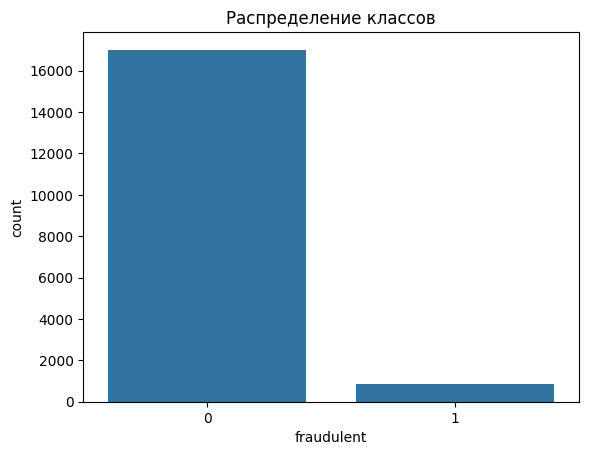

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='fraudulent', data=df)
plt.title("Распределение классов")
plt.show()

In [11]:
df.duplicated().sum()

np.int64(248)

In [12]:
df.drop_duplicates()

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"<h3>We're Food52, and we've created a groundbr...","<p>Food52, a fast-growing, James Beard Award-w...",<ul>\r\n<li>Experience with content management...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"<h3>90 Seconds, the worlds Cloud Video Product...",<p>Organised - Focused - Vibrant - Awesome!<br...,<p><b>What we expect from you:</b></p>\r\n<p>Y...,<h3><b>What you will get from us</b></h3>\r\n<...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,<h3></h3>\r\n<p>Valor Services provides Workfo...,"<p>Our client, located in Houston, is actively...",<ul>\r\n<li>Implement pre-commissioning and co...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,<p>Our passion for improving quality of life t...,<p><b>THE COMPANY: ESRI – Environmental System...,<ul>\r\n<li>\r\n<b>EDUCATION: </b>Bachelor’s o...,<p>Our culture is anything but corporate—we ha...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,<p>SpotSource Solutions LLC is a Global Human ...,<p><b>JOB TITLE:</b> Itemization Review Manage...,<p><b>QUALIFICATIONS:</b></p>\r\n<ul>\r\n<li>R...,<p>Full Benefits Offered</p>,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17875,Account Director - Distribution,"CA, ON, Toronto",Sales,NaN,<p>Vend is looking for some awesome new talent...,<p>Just in case this is the first time you’ve ...,<p>To ace this role you:</p>\r\n<ul>\r\n<li>Wi...,<p><b>What can you expect from us?</b></p>\r\n...,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Sales,0
17876,Payroll Accountant,"US, PA, Philadelphia",Accounting,NaN,<p>WebLinc is the e-commerce platform and serv...,<p></p>\r\n<p>The Payroll Accountant will focu...,<p></p>\r\n<p>- B.A. or B.S. in Accounting</p>...,<p></p>\r\n<h3>Health &amp; Wellness</h3>\r\n<...,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Internet,Accounting/Auditing,0
17877,Project Cost Control Staff Engineer - Cost Con...,"US, TX, Houston",NaN,NaN,<p>We Provide Full Time Permanent Positions fo...,<p>Experienced Project Cost Control Staff Engi...,<ul>\r\n<li>At least 12 years professional exp...,NaN,0,0,0,Full-time,NaN,NaN,NaN,NaN,0
17878,Graphic Designer,"NG, LA, Lagos",NaN,NaN,NaN,<p>Nemsia Studios is looking for an experience...,<p>1. Must be fluent in the latest versions of...,<p>Competitive salary (compensation will be ba...,0,0,1,Contract,Not Applicable,Professional,Graphic Design,Design,0


проверка показала наличие дубликатов.они были удалены чтобы избежать искажения результатов

теперь перйдём к пропускам 

In [13]:
df.isnull().sum().sort_values(ascending=False)

salary_range           15012
department             11547
required_education      8105
benefits                7196
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2689
location                 346
title                      0
telecommuting              0
has_questions              0
has_company_logo           0
description                0
fraudulent                 0
dtype: int64

Высокое количество пропусков может означать, что:

данные признаки редко заполняются работодателями
отсутствие информации само по себе может быть информативным признаком

In [14]:
df['has_salary'] = df['salary_range'].notnull().astype(int)

In [15]:
df = df.drop(columns=['department'])

In [16]:
text_cols = ['company_profile', 'requirements', 'benefits']

for col in text_cols:
    df[col] = df[col].fillna('')

Для признака salary_range было решено создать бинарный признак has_salary, отражающий наличие информации о зарплате.

Признак department был удалён из-за большого количества пропусков и низкой информативности.

Текстовые признаки (company_profile, requirements, benefits) были заполнены пустыми строками, так как они будут использоваться при обработке текста.

In [17]:
cols = ['telecommuting', 'has_company_logo', 'has_questions', 'has_salary']

for col in cols:
    print(col)
    print(df.groupby(col)['fraudulent'].mean())
    print()

telecommuting
telecommuting
0    0.046865
1    0.083442
Name: fraudulent, dtype: float64

has_company_logo
has_company_logo
0    0.159290
1    0.019902
Name: fraudulent, dtype: float64

has_questions
has_questions
0    0.067782
1    0.028435
Name: fraudulent, dtype: float64

has_salary
has_salary
0    0.042832
1    0.077755
Name: fraudulent, dtype: float64



Признак has_company_logo показывает, что вакансии без логотипа чаще являются мошенническими.
Признак has_salary показывает, что вакансии с указанной зарплатой имеют более высокую вероятность быть мошенническими.
Это может быть связано с тем, что мошенники часто используют привлекательные зарплаты для привлечения внимания.
А также наличие вопросов (has_questions) снижает вероятность мошенничества, что может указывать на более серьёзный подход работодателя.
Удалённые вакансии (telecommuting) имеют более высокую вероятность мошенничества

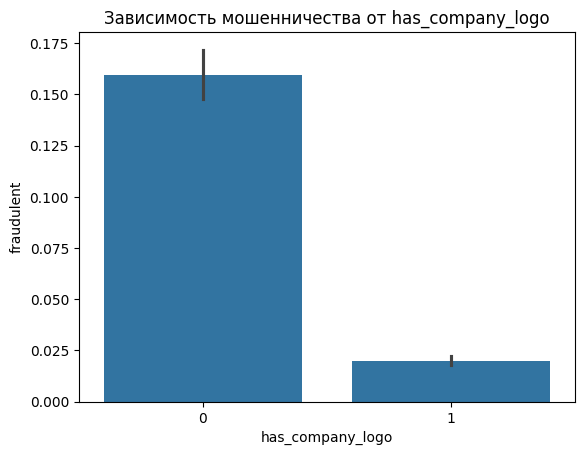

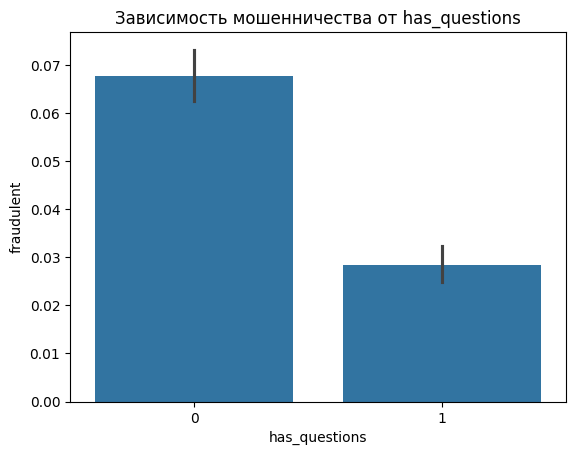

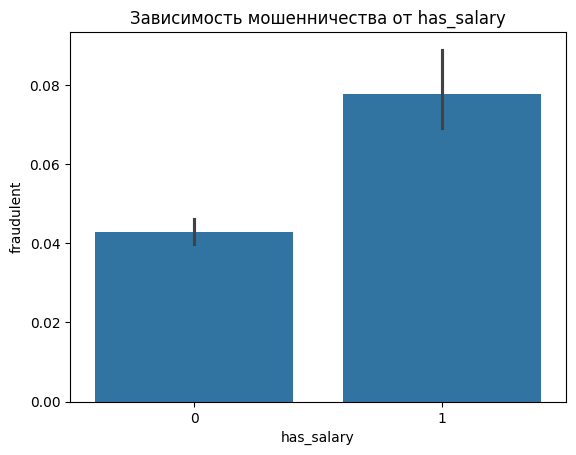

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['has_company_logo', 'has_questions', 'has_salary']:
    sns.barplot(x=col, y='fraudulent', data=df)
    plt.title(f'Зависимость мошенничества от {col}')
    plt.show()

In [19]:
df['text_length'] = df['description'].apply(len)

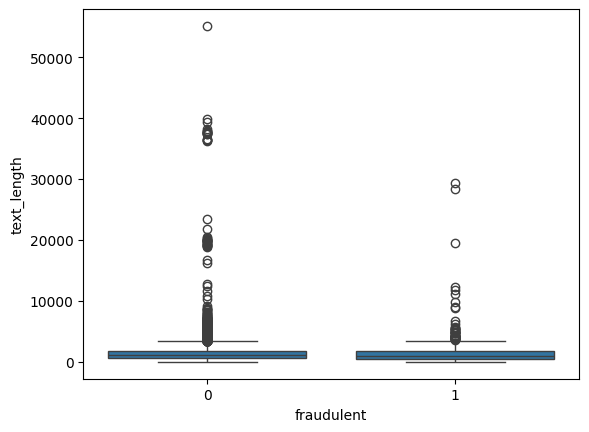

In [20]:
sns.boxplot(x='fraudulent', y='text_length', data=df)
plt.show()

Длина описания вакансии различается между классами, что может быть использовано как дополнительный признак.

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english', max_features=20)

X = vectorizer.fit_transform(df['description'])

print(vectorizer.get_feature_names_out())

['br' 'business' 'company' 'customer' 'development' 'experience' 'false'
 'li' 'locked' 'looking' 'lsdexception' 'management' 'new' 'priority'
 'product' 'sales' 'service' 'team' 'ul' 'work']


In [22]:
df.to_csv("../data/processed/processed_jobs.csv", index=False)